# Linear Regression with scikit-learn                                                     
                                                                                            
In the previous notebook we implemented linear regression three ways from scratch:        
Normal Equations, Batch Gradient Descent, and Stochastic Gradient Descent.                
Now we replicate the same models using scikit-learn.                      
                                                                                          
The goal is to:                                                                          
- **Learn the sklearn API**, the standard tool for ML in practice                         
                                                                 
We use the same ZonaProp dataset (32,585 CABA properties) and the same                    
train/test split so results are directly comparable.                                      
                                                                                          
## Models                                                                                 
- `LinearRegression` — sklearn's closed-form solver (equivalent to our Normal Equations)  
- `SGDRegressor` — sklearn's stochastic gradient descent (equivalent to our SGD)

### Imports

In [1]:
import numpy as np
import pandas as pd                                                                       
import matplotlib.pyplot as plt
                                                                                          
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split                                      
from sklearn.metrics import mean_absolute_error, r2_score

### Load data

In [2]:
df = pd.read_csv("data/zonaprop_clean.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (32585, 7)


,precio,expensas,metros,ambientes,banos,barrio,comuna
0,530000.0,770000,172.0,4.0,3.0,PALERMO,14
1,170000.0,0,73.0,4.0,1.0,VILLA CRESPO,15
2,120000.0,260000,54.0,3.0,1.0,RECOLETA,2
3,220000.0,380073,68.0,3.0,2.0,NUÑEZ,13
4,84100.0,110000,55.0,1.0,1.0,VILLA LURO,10


### Features and target

In [3]:
feature_cols = ["metros", "ambientes", "banos"]
X = df[feature_cols].values.astype(float)
y = df["precio"].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}")                                                          
print(f"Test:  {X_test.shape}")

Train: (26068, 3)
Test:  (6517, 3)


### Normalize features

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)                                            
X_test_scaled  = scaler.transform(X_test)
                                                                                          
print(f"Peak to Peak range by column in Raw        X: {np.ptp(X_train, axis=0)}")         
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_train_scaled, axis=0)}")
print(f"\nMean  (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")                  
print(f"Std   (should be ~1): {X_train_scaled.std(axis=0).round(4)}")                     

Peak to Peak range by column in Raw        X: [475.   9.   5.]
Peak to Peak range by column in Normalized X: [5.91394651 6.25561229 6.18617351]

Mean  (should be ~0): [0. 0. 0.]
Std   (should be ~1): [1. 1. 1.]


## 1. LinearRegression

In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print(f"Intercept: {lr.intercept_:,.2f}")
print(f"Coefs:     {dict(zip(feature_cols, lr.coef_.round(2)))}")  

Intercept: 276,384.39
Coefs:     {'metros': np.float64(141474.24), 'ambientes': np.float64(-37860.22), 'banos': np.float64(94456.63)}


### Predict 

In [7]:
y_pred = lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)                                                            
                
print(f"MAE: USD {mae:,.0f}")                                                             
print(f"R²:      {r2:.4f}")


MAE: USD 102,806
R²:      0.5146


### Plot

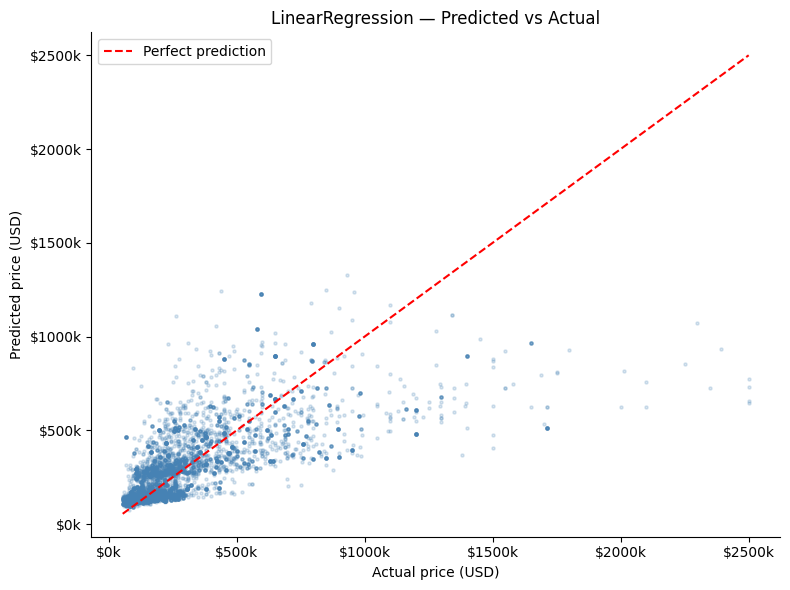

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))                                                    
                                                                                          
ax.scatter(y_test, y_pred, alpha=0.2, s=5, color="steelblue")                             
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],                                                     
        color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
                                                                                          
ax.set_xlabel("Actual price (USD)")
ax.set_ylabel("Predicted price (USD)")                                                    
ax.set_title("LinearRegression — Predicted vs Actual")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))           
ax.legend()                                                                               
ax.spines["top"].set_visible(False)                                                       
ax.spines["right"].set_visible(False)                                                     
plt.tight_layout()                                                                        
plt.show()

## 2. SGDRegressor

In [13]:
sgd = SGDRegressor(max_iter=1000, random_state=42, eta0=0.01)                   
sgd.fit(X_train_scaled, y_train)                                                          
                
print(f"Intercept: {sgd.intercept_[0]:,.2f}")                                             
print(f"Coefs:     {dict(zip(feature_cols, sgd.coef_.round(2)))}")
print(f"Number of iters: {sgd.n_iter_}")

Intercept: 276,145.06
Coefs:     {'metros': np.float64(138584.24), 'ambientes': np.float64(-39787.8), 'banos': np.float64(91310.13)}
Number of iters: 9


### Predict

In [14]:
y_pred_sgd = sgd.predict(X_test_scaled)                                                   
                                                                                          
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)                                         
r2_sgd  = r2_score(y_test, y_pred_sgd)
                                                                                          
print(f"MAE: USD {mae_sgd:,.0f}")
print(f"R²:      {r2_sgd:.4f}")

MAE: USD 102,951
R²:      0.5146


### Plot

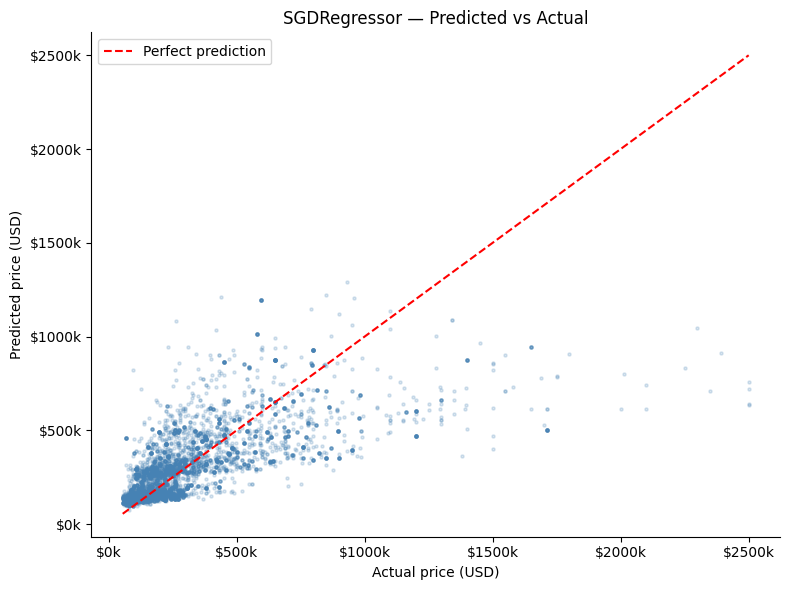

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))                                                    
                  
ax.scatter(y_test, y_pred_sgd, alpha=0.2, s=5, color="steelblue")                         
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],                                                     
        color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual price (USD)")                                                       
ax.set_ylabel("Predicted price (USD)")
ax.set_title("SGDRegressor — Predicted vs Actual")                                        
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))           
ax.legend()
ax.spines["top"].set_visible(False)                                                       
ax.spines["right"].set_visible(False)                                                     
plt.tight_layout()
plt.show() 

## 3. Summary

In [16]:
print(f"{'Model':<20} {'MAE (USD)':<20} {'R²'}")                                          
print(f"{'─'*45}")                                                                        
print(f"{'LinearRegression':<20} {mae:.<20,.0f} {r2:.4f}")                                
print(f"{'SGDRegressor':<20} {mae_sgd:<20,.0f} {r2_sgd:.4f}")                       

Model                MAE (USD)            R²
─────────────────────────────────────────────
LinearRegression     102,806............. 0.5146
SGDRegressor         102,951              0.5146
